[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/29%20-%20Feature%20extraction%20using%20OpenCV%20and%20SIFT/Feature_extraction_using_OpenCV_and_SIFT.ipynb)

# Overview

Prior to Deep CNNs, [SIFT](http://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_feature2d/py_sift_intro/py_sift_intro.html) provided the best technology for identifying objects between images.

### Scale-Invariant Feature Transform

We will try to apply the SIFT algorithm to some images and see if we can find the keypoints, and then using a train and test image we'll try to see if we can create some threshold for identifying if a given image was found.

# Data

Train image

In [1]:
!wget https://www.dropbox.com/s/yz1dmhovmunschi/can-87993_960_720.jpg?raw=1 -O coke.jpg

--2018-11-13 00:54:13--  https://www.dropbox.com/s/yz1dmhovmunschi/can-87993_960_720.jpg?raw=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.9.1, 2620:100:601f:1::a27d:901
Connecting to www.dropbox.com (www.dropbox.com)|162.125.9.1|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/raw/yz1dmhovmunschi/can-87993_960_720.jpg [following]
--2018-11-13 00:54:13--  https://www.dropbox.com/s/raw/yz1dmhovmunschi/can-87993_960_720.jpg
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uca60922fc58cd96193f1fce0521.dl.dropboxusercontent.com/cd/0/inline/AVeZzALkBZ5yLVABsVXZk6Brnj37vKu9meuYpND6nWzzBQ6MoKoi3UFRaTR6fItVsHlwC0leFZTGiDYObdZXaC6IORL4ICa5NiaaigTOj1zp27tbf4zRZhJy8VP-H-wFMqe0cZQXB7vHOpSz2423WrbJ0V_uGPUXDoRq6qmTrDU6ZOvLZvHwpnidF2myw5L_3ww/file [following]
--2018-11-13 00:54:14--  https://uca60922fc58cd96193f1fce0521.dl.dropboxusercontent.com/cd/0/inline/AVeZzALkBZ5yLVABsV

Test image

In [4]:
!wget https://www.dropbox.com/s/gnw2lt7lstm5ta8/coca-cola-cold-drink-soft-drink-coke-50593.jpeg?raw=1 -O coke-test.jpg

--2018-11-13 00:58:24--  https://www.dropbox.com/s/gnw2lt7lstm5ta8/coca-cola-cold-drink-soft-drink-coke-50593.jpeg?raw=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.8.1, 2620:100:601f:1::a27d:901
Connecting to www.dropbox.com (www.dropbox.com)|162.125.8.1|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/raw/gnw2lt7lstm5ta8/coca-cola-cold-drink-soft-drink-coke-50593.jpeg [following]
--2018-11-13 00:58:24--  https://www.dropbox.com/s/raw/gnw2lt7lstm5ta8/coca-cola-cold-drink-soft-drink-coke-50593.jpeg
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3d33120fb8247ce077891f143c.dl.dropboxusercontent.com/cd/0/inline/AVdjDekOausygemevCbFrtcMuJdmmhQAwSN3XoXQCI1ykK22Rk7Q_YGBqB8Br2qMGSVv5QK1wjZzxYpFpCM3COsIeKiG-Zq2VVkzKpsu3oq4vdurjnq8He1rQIp9M2-v7AgXDyTJD2e16ngnTM_TD5MKXsTCT9WctCHiEa78dx-YNIASME46z87Pr0nVq3IEmQY/file [following]
--2018-11-13 00:58:24--  https://uc3d331

# OpenCV SIFT

In [2]:
# Reinstalling opencv - the public distribution of OpenCV does not include SIFT,
# an algorithm patented by David Lowe and his university.
!pip uninstall -y opencv-python
!pip install opencv-contrib-python==3.4.1.15

Uninstalling opencv-python-3.4.3.18:
  Successfully uninstalled opencv-python-3.4.3.18
    100% |████████████████████████████████| 30.3MB 1.1MB/s 


[(82.20227813720703, 410.67535400390625), (86.43980407714844, 474.2742614746094), (88.64251708984375, 453.4048767089844), (90.82734680175781, 420.3274230957031), (91.71968841552734, 470.5218505859375), (93.63848114013672, 463.6846618652344), (94.10944366455078, 470.2672424316406), (97.29999542236328, 399.68646240234375), (97.8148422241211, 467.6947937011719), (98.10584259033203, 432.9391784667969), (99.9940185546875, 491.5755615234375), (102.07459259033203, 398.7119445800781), (105.09852600097656, 446.98388671875), (108.06791687011719, 443.1422119140625), (111.71064758300781, 450.0743713378906), (112.1600570678711, 498.427734375), (112.82887268066406, 505.9836120605469), (112.82887268066406, 505.9836120605469), (113.1111068725586, 440.79608154296875), (113.1111068725586, 440.79608154296875), (115.73479461669922, 443.54046630859375), (117.86666870117188, 505.45379638671875), (117.86666870117188, 505.45379638671875), (118.1956787109375, 404.1327819824219), (118.43341064453125, 440.853576

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


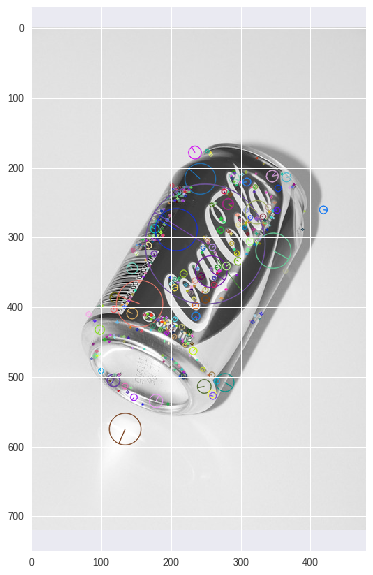

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert to grayscale (SIFT does not work with color)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# SIFT object
sift = cv2.xfeatures2d.SIFT_create()

# SIFT keypoint detection with DoG Kernel and Scale Space
kp = sift.detect(gray, None)
points = [each.pt for each in kp]
print(points)

# Draw detected features on output image
cv2.drawKeypoints(gray, kp, out, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(6, 10))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.axes().set_aspect('equal', 'datalim');

### Apply the same to the test image

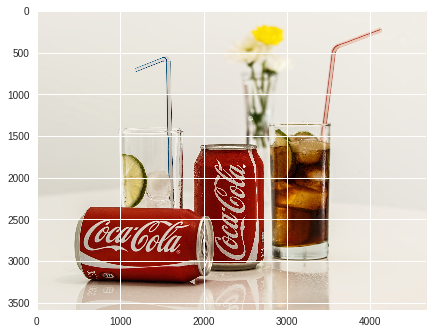

In [5]:
test = cv2.imread('coke-test.jpg')
test_out = cv2.imread('coke-test.jpg')

plt.imshow(cv2.cvtColor(test, cv2.COLOR_BGR2RGB));

[455.6964416503906, 513.1983032226562, 515.521484375, 515.68798828125, 516.1207885742188, 520.4776611328125, 520.4776611328125, 524.7665405273438, 525.9641723632812, 526.220703125, 535.904541015625, 538.2451171875, 540.6948852539062, 540.6948852539062, 541.25732421875, 542.2318725585938, 543.7249755859375, 545.7724609375, 545.7724609375, 549.5363159179688, 565.8704223632812, 565.8704223632812, 566.3198852539062, 569.8869018554688, 573.5645751953125, 577.9400024414062, 581.9525756835938, 595.8221435546875, 597.8426513671875, 602.2122802734375, 604.9263305664062, 609.7735595703125, 612.2726440429688, 617.8967895507812, 618.8348999023438, 619.0834350585938, 622.6388549804688, 622.8129272460938, 622.8129272460938, 623.6409912109375, 623.7102661132812, 623.8812255859375, 625.34130859375, 630.7289428710938, 631.0224609375, 633.0143432617188, 633.455322265625, 634.51123046875, 638.4471435546875, 638.4471435546875, 638.4622192382812, 640.0416870117188, 640.0416870117188, 643.8143920898438, 643

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


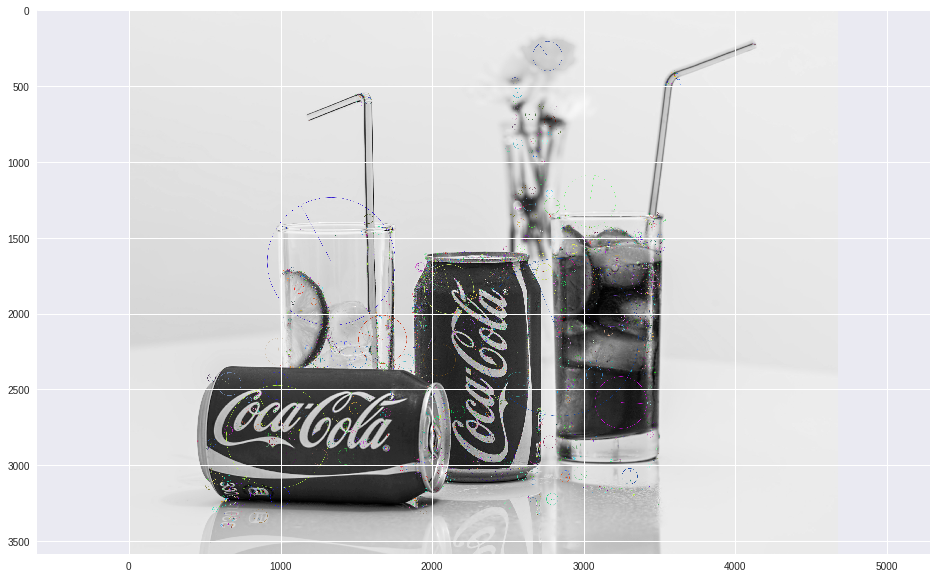

In [6]:
test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

kp_2 = sift.detect(test_gray, None)
points_2 = [each.pt[0] for each in kp_2]
print(points_2)

cv2.drawKeypoints(test_gray, kp_2, test_out, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(test_out, cv2.COLOR_BGR2RGB))
plt.axes().set_aspect('equal', 'datalim');

**Observation:** 

Can we say visually that the algorithm has identified similar features between the train and the test image? 

May be – there does seem similar points if one looks closely, but hard to be sure. Let's see how we can fix that.

# Indentifying an Image

We'll use the [BFMatcher](https://docs.opencv.org/3.0-beta/doc/py_tutorials/py_feature2d/py_matcher/py_matcher.html)

And the idea here is simple:  We take the descriptors from both the images (train and test) – and try to find close enough matching pairs using distance calculations in a Brute Force manner.

In [0]:
def drawMatches(img1, kp1, img2, kp2, matches):
  rows1 = img1.shape[0]
  cols1 = img1.shape[1]
  rows2 = img2.shape[0]
  cols2 = img2.shape[1]

  out = np.zeros((max([rows1, rows2]), cols1 + cols2, 3), dtype='uint8')
  out[:rows1, :cols1] = np.dstack([img1])
  out[:rows2, cols1:] = np.dstack([img2])
  for mat in matches:
    img1_idx = mat.queryIdx
    img2_idx = mat.trainIdx
    (x1,y1) = kp1[img1_idx].pt
    (x2,y2) = kp2[img2_idx].pt

    cv2.circle(out, (int(x1), int(y1)), 4, (255, 0, 0, 1), 1)   
    cv2.circle(out, (int(x2) + cols1, int(y2)), 4, (255, 0, 0, 1), 1)
    cv2.line(out, (int(x1), int(y1)), (int(x2) + cols1, int(y2)), (255, 0, 0, 1), 1)

  return out

In [0]:
kp1, des1 = sift.detectAndCompute(gray, None)
kp2, des2 = sift.detectAndCompute(test_gray, None)

bf = cv2.BFMatcher()
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda val: val.distance)

final_output = drawMatches(gray, kp1, test_gray, kp2, matches[:25])

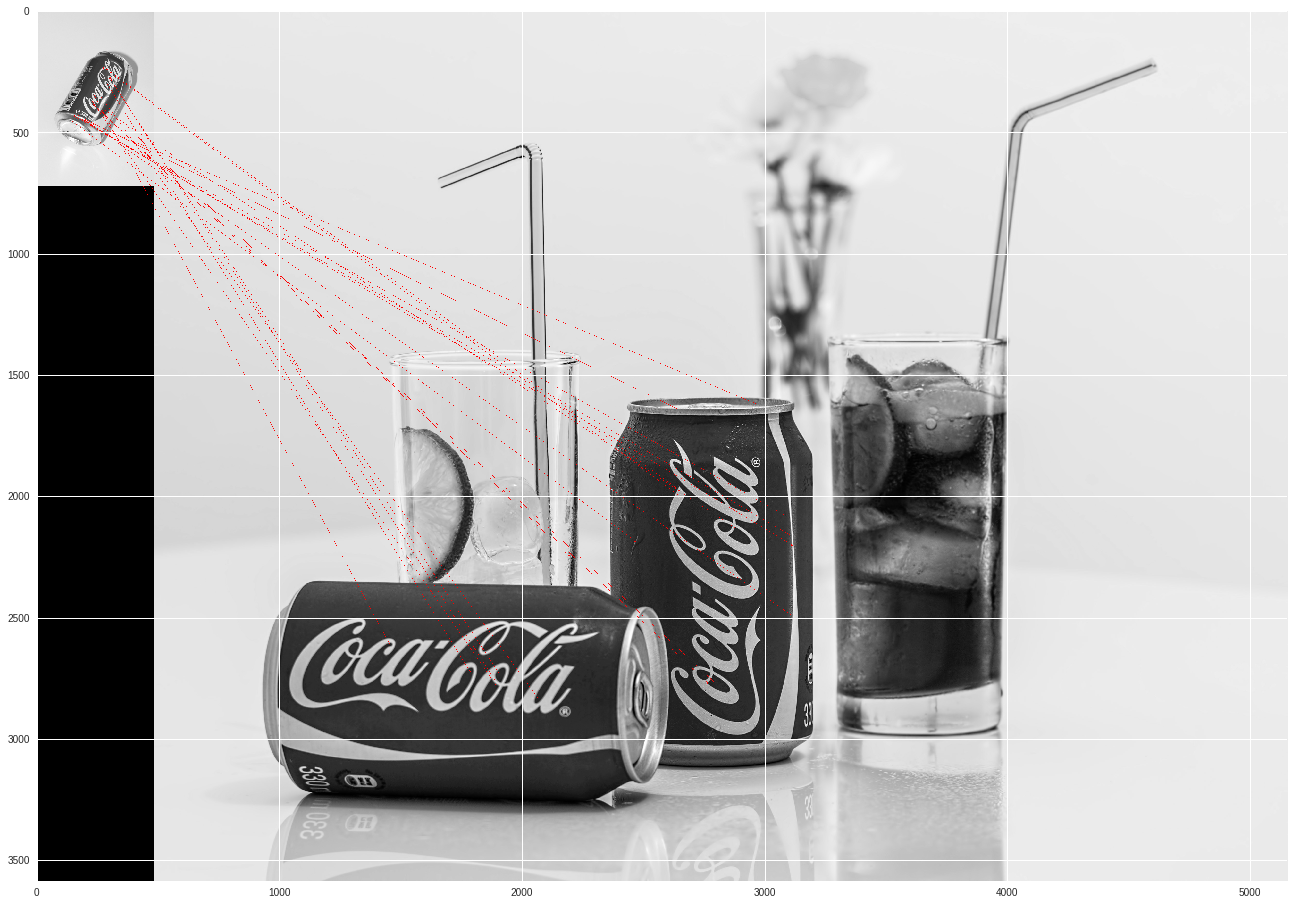

In [12]:
plt.figure(figsize=(24, 16))
plt.imshow(final_output);